# Lecture 3 — Linear Value Function Approximation

**Reinforcement Learning, 2025-26**

## Where we are

In the first part of the course you studied tabular methods, in which the action-value function is represented exactly: one number $Q(s, a)$ for each state-action pair, stored in a table. Lectures 1 and 2 made these methods operational — you saw Q-learning, SARSA, and Monte Carlo learn cliff-edge or cautious policies on a small grid world, and you learned to read learning curves, policies, and visit counts as diagnostic signals.

The story of this lecture begins where that representation breaks down. Real problems rarely have small finite state spaces. Robots have continuous joint angles. Trading agents face continuous prices. Even a one-celled microbe in a Petri dish, when we stop pretending its world is divided into cells, lives in a continuum.

This lecture introduces **value function approximation** — the family of methods that represent $V$ or $Q$ as a parametric function $\hat{v}(s, \mathbf{w})$ or $\hat{q}(s, a, \mathbf{w})$ rather than as a table — and develops the simplest member of that family in detail: the *linear* case, where $\hat{v}(s, \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$ for some feature map $\mathbf{x}(\cdot)$.

## What you will learn today

By the end of this lecture you will be able to:

1. Explain *why* tabular methods fail on continuous-state problems, beyond the surface fact that a table cannot index a real number.
2. Construct simple feature maps — **tile coding** and **radial basis functions** — that turn a continuous state into a useful set of features for linear approximation.
3. Implement and apply a linear **TD(0)** prediction agent for evaluating a fixed policy on a continuous-state environment, and read the resulting learned value functions.
4. Recognise *semi-gradient* TD methods and understand why the "semi" qualifier is not a formality but a substantive caveat about what is and is not being optimised.

This lecture covers prediction only — the problem of learning $V^\pi$ for a *given* policy. Control with function approximation, and the new failure modes it introduces, is the topic of Lecture 4.

## How we will get there

We open by introducing a continuous-state version of the microbe environment — `ContinuousMicrobeEnv` — and asking what would happen if we tried to apply tabular Q-learning to it. We walk through the symptoms of the failure (it is more interesting than just "the table has infinite rows") and use them to motivate the change of representation. We then introduce linear value function approximation as a deliberate trade-off: we accept that the value function is no longer represented exactly, in exchange for the ability to *generalise* between similar states.

The bulk of the lecture is spent on this trade-off. Feature construction is the lever that controls it: choose features well, and similar states get similar values; choose them poorly, and the agent learns nothing useful. We will see two standard feature families — tile coding and RBFs — applied to the same environment and the same evaluation problem, so that the influence of the feature design becomes visible.

The final section turns to learning. We extend TD(0) from the tabular setting to the linear setting, derive the corresponding gradient update, and observe the *semi-gradient* phenomenon: the surprising fact that in TD with function approximation we are not actually following the gradient of the loss we appear to be minimising. We will see why this matters more in Lecture 4 than today, but the seed is planted now.

The agent we build today lives in `rlc/agents/linear_td.py`; the new environment lives in `rlc/envs/continuous_microbe.py`; the feature extractors live in a new subpackage, `rlc/features/`.

## The problem: a microbe in continuous water

Until now we treated the microbe's habitat as a grid of discrete cells. A microbe that takes a step from cell $(3, 0)$ to cell $(3, 1)$ jumps an entire cell width in one time unit, with no notion of *partial* movement. The grid was a useful abstraction — it gave us a finite set of states to enumerate, a Q-table to fill, and convergence guarantees that hold in the tabular setting. But the abstraction is not free: it imposed a discrete structure on a fundamentally continuous physical situation.

Imagine the same microbe in the same Petri dish, with the same nutrient source and the same toxic gradient — but no grid. The microbe's position is now a point $(x, y) \in [0, W] \times [0, H]$, free to take any real value within the bounding rectangle. When it commands a movement, the resulting displacement need not align with cell boundaries: the microbe can be at position $(3.27, 1.84)$, take a step to the right, and end up at $(4.21, 1.92)$ — close to where it would have been on the grid, but not at any privileged location. The toxic and nutrient regions are not cells but *regions* of the plane.

Two consequences of this physical update deserve attention.

1. **The first is that *similar* states are no longer the same state**. On the grid, $(3, 1)$ and $(4, 1)$ were two distinct entities, identified only by their integer indices: nothing in the representation said they were "close". In the continuum, $(3.27, 1.84)$ and $(3.31, 1.85)$ are *almost* the same point, and any reasonable agent should treat them as essentially equivalent. Whatever the value of $V$ at the first, the value at the second should be very nearly the same. This is the property the grid representation was unable to express, and it is the property we will exploit today.

2. **The second is that the number of possible states is no longer finite**. The Petri dish $[0, W] \times [0, H]$ has uncountably many points. We cannot maintain a table indexed by every possible state, because there is no enumeration. This is the obvious failure of the tabular method on continuous problems, but as we will see, it is the *less* interesting failure: even if we could fit a giant table, treating each state as independent would still be wrong.

Action-wise, the microbe still has four discrete options — up, right, down, left — each of which produces a fixed displacement of $\Delta = 1.0$ in the corresponding direction. Discretizing the action space, while the state space is continuous, is a common and entirely acceptable design choice; it suits problems where the agent's repertoire of possible behaviours is finite, even if its situation is not.

Let us also acknowledge that the Petri dish is not a vacuum. The fluid in which the microbe swims has thermal motion of its own, and a real biological organism does not execute its motor commands with perfect precision. We will reflect this with **a *noise* parameter**, which adds Gaussian fluctuations to the displacement vector at every step. The deterministic case (no noise) and the stochastic case (with noise) will both be available, controlled by a single parameter — analogously to the `slippery` parameter of the discrete environment, but **acting on the *outcome of the displacement* rather than on the *identity of the action*. The two are different ways of making the world stochastic**; we will discuss the distinction when we formalise the MDP.

The next section turns this informal description into a precise mathematical specification. After that, we ask the question that motivates the rest of the lecture: *what would happen if we tried to apply tabular Q-learning to this environment?*

## The MDP

Let $W$ and $H$ denote the width and height of the Petri dish. The state is the microbe's position in the dish, encoded as a real-valued vector.

**State space.** The state is a point in the bounding rectangle:

$$\mathcal{S} = [0, W] \times [0, H] \subset \mathbb{R}^2.$$

A non-empty closed *toxic region* $\mathcal{R}_{\text{toxic}} \subset \mathcal{S}$ and a closed *goal region* $\mathcal{R}_{\text{goal}} \subset \mathcal{S}$, with $\mathcal{R}_{\text{toxic}} \cap \mathcal{R}_{\text{goal}} = \emptyset$, are fixed parameters of the environment. The starting position $s_{\text{start}} \in \mathcal{S} \setminus (\mathcal{R}_{\text{toxic}} \cup \mathcal{R}_{\text{goal}})$ is also fixed.

**Action space.** Four discrete actions corresponding to the cardinal directions:

$$\mathcal{A} = \{0, 1, 2, 3\} = \{\uparrow, \to, \downarrow, \leftarrow\},$$

with the same convention adopted throughout the course. Each action $a$ is associated with a displacement vector $\boldsymbol{\Delta}(a) \in \mathbb{R}^2$ of fixed length $\Delta$: $\boldsymbol{\Delta}(\uparrow) = (0, -\Delta)$, $\boldsymbol{\Delta}(\to) = (+\Delta, 0)$, $\boldsymbol{\Delta}(\downarrow) = (0, +\Delta)$, $\boldsymbol{\Delta}(\leftarrow) = (-\Delta, 0)$.

**Stochastic dynamics.** A parameter $\sigma \geq 0$ controls additive noise on the displacement. Given current state $s$ and commanded action $a$, the *intended landing point* is

$$L(s, a) = \mathrm{clip}\big(s + \boldsymbol{\Delta}(a) + \boldsymbol{\eta}, \; \mathcal{S}\big), \qquad \boldsymbol{\eta} \sim \mathcal{N}(\mathbf{0}, \sigma^2 I_2),$$

where $\mathrm{clip}(\cdot, \mathcal{S})$ projects componentwise onto the rectangle $[0, W] \times [0, H]$. The deterministic case corresponds to $\sigma = 0$.

It is worth noting that this stochasticity model is structurally different from the `slippery` parameter of `MicrobeGridEnv`. There, randomness perturbed the *identity of the action*: with probability $p$ the commanded action was replaced by a perpendicular one. Here, the action is always executed as commanded, but the *outcome of the displacement* is corrupted by additive noise: the microbe attempts to move in the chosen direction but the fluid pushes it slightly in another direction, by a small random amount. Both are legitimate models of stochastic dynamics and either could in principle be used; the additive-noise model is a closer match to the physical narrative of Brownian motion in a viscous fluid, and it is the one we adopt.

**Step dynamics.** Given current state $s$ and commanded action $a$, the next state, reward, and termination flag are determined by the location of the intended landing point $L = L(s, a)$:

| Condition on $L$                        | Next state $s'$    | Reward $r$ | Terminal? |
|-----------------------------------------|--------------------|------------|-----------|
| $L \in \mathcal{R}_{\text{goal}}$       | $L$                | $-1$       | yes       |
| $L \in \mathcal{R}_{\text{toxic}}$      | $s_{\text{start}}$ | $-100$     | no        |
| otherwise                               | $L$                | $-1$       | no        |

Toxic regions trigger a teleport to the start, exactly as in the discrete case; the goal region terminates the episode upon entry.

**Initial state distribution.** Deterministic at the start position:

$$\rho_0(s) = \delta(s - s_{\text{start}}).$$

**Discount factor.** Undiscounted episodic: $\gamma = 1$.

**Default configuration.** Throughout this lecture we use $W = 12$, $H = 6$, $\Delta = 1.0$, $s_{\text{start}} = (0.5, 5.5)$, $\mathcal{R}_{\text{goal}} = \{s : \|s - (11.5, 5.5)\|_2 \leq 0.5\}$ (a disc of radius $0.5$ around the bottom-right corner), and $\mathcal{R}_{\text{toxic}} = [1, 11] \times [4.5, 5.5]$ (the rectangle along the bottom row, between start and goal). The deterministic case ($\sigma = 0$) is the default; the stochastic version is enabled by passing $\sigma > 0$ to the environment constructor. With these parameters, a tabular agent that discretized the dish into unit cells would recover an environment essentially identical to `MicrobeGridEnv` of Lecture 1 — a fact we will exploit for diagnostic comparisons.

### Implementation of the new environment

A few comments on `ContinuousMicrobeEnv`.

- **Class**: The class structurally mirrors `MicrobeGridEnv` of Lecture 1. The same constructor pattern, the same validation strategy, the same separation between intended-landing computation and step dynamics, the same rendering approach with a microbe disc colored by cumulative return. What changes is contained: positions are 2D floats, regions are continuous subsets of the plane, and the displacement noise is additive Gaussian rather than action-perpendicular. Reading the two modules side by side is the cleanest way to internalise the difference between a discrete and a continuous formulation of the same problem.

- **Observetion space**:The observation space is `Box(low=[0, 0], high=[W, H], dtype=float32)`. Note the `float32`: while we use `float64` internally for accuracy, we expose `float32` to agents — this matches the convention used by Gymnasium's classic-control environments and is the default for most function approximation libraries (in particular, PyTorch tensors are usually `float32`). An agent reading `obs` and feeding it directly to a neural network will not need any casting.

- **Noise**: The `noise` parameter is implemented via additive Gaussian perturbation on the displacement vector, drawn from `self.np_random` — the seeded NumPy generator inherited from `gym.Env`. This guarantees reproducibility: passing the same seed to `reset` produces the same sequence of perturbations across runs, just as for `MicrobeGridEnv`.

- **Regions**: Region membership is decided on the *post-displacement, post-clip* position, not on the trajectory between current and landing positions. With $\Delta = 1$ and reasonably wide regions, the difference is irrelevant in practice; with very thin regions or large displacements the trajectory might cross a region without the landing point being inside it, and the environment would miss the event. This is a standard simplification of grid-like continuous environments; if it ever became a problem, one would replace it with explicit segment-region intersection tests.

- **Future smooth reward**: The constructor exposes a `smooth_reward` flag with default `False`. When set to `True` it currently raises `NotImplementedError`: the smooth-reward variant is reserved for later lectures, where a continuous reward field replacing the $-1$/$-100$ scheme will let us study how reward shaping interacts with function approximation. The flag is in the API now so that future activations are non-disruptive.

- **Info**: The `info` dictionary returned by `step` includes `landing_before_teleport`, the position the microbe would have ended up in had the toxic teleport not fired. For non-toxic transitions this coincides with the new state; for toxic transitions it lets external code (loggers, visualizers) observe *where* in the toxic region the microbe was before being sent back to the start. We will not use this in Lecture 3, but it is the sort of diagnostic info that is cheap to expose and inconvenient to add later.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

from rlc.envs.continuous_microbe import ContinuousMicrobeEnv

env = ContinuousMicrobeEnv(render_mode="rgb_array")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Render modes:      {env.metadata['render_modes']}")

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}  (type={type(obs).__name__}, dtype={obs.dtype})")
print(f"Is in observation_space? {env.observation_space.contains(obs)}")

Observation space: Box(0.0, [12.  6.], (2,), float32)
Action space:      Discrete(4)
Render modes:      ['rgb_array']
Initial observation: [0.5 5.5]  (type=ndarray, dtype=float32)
Is in observation_space? True


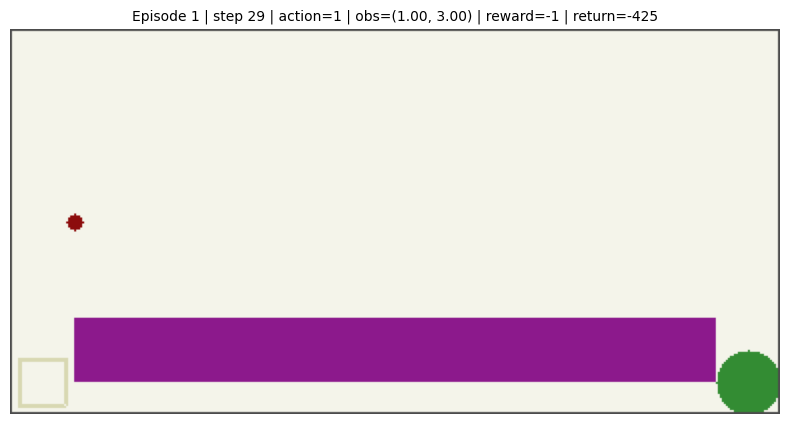

In [2]:
def show_frame(frame, title):
    plt.figure(figsize=(10, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

TOTAL_FRAMES = 30
FRAME_DELAY = 0.25

episode = 1
ep_step = 0
ep_return = 0.0

obs, info = env.reset(seed=0)
show_frame(env.render(),
           title=f"Episode {episode} | step 0 | start (obs=({obs[0]:.2f}, {obs[1]:.2f}))")
time.sleep(FRAME_DELAY)

for _ in range(TOTAL_FRAMES - 1):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    ep_step += 1
    ep_return += reward

    clear_output(wait=True)
    show_frame(
        env.render(),
        title=(f"Episode {episode} | step {ep_step} | action={action} | "
               f"obs=({obs[0]:.2f}, {obs[1]:.2f}) | reward={reward:.0f} | "
               f"return={ep_return:.0f}")
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        time.sleep(FRAME_DELAY * 2)
        episode += 1
        ep_step = 0
        ep_return = 0.0
        obs, info = env.reset()
        clear_output(wait=True)
        show_frame(env.render(),
                   title=f"Episode {episode} | step 0 | start (obs=({obs[0]:.2f}, {obs[1]:.2f}))")
        time.sleep(FRAME_DELAY)

env.close()

## A naive idea: discretize the state

The most direct way to apply what we already know to the new environment is to refuse the new environment. We could decide that the microbe's continuous coordinates are an inconvenient detail, partition the dish into a grid of cells, and pretend the only thing the agent observes is which cell it is in. From the agent's perspective the world becomes discrete again, and we can plug `QLearningAgent` straight in without writing a single new line of agent code.

This is not a foolish thing to try. It would, in principle, work. It is also a useful starting point precisely because it *is* the simplest possible answer to the continuous-state problem, and seeing where it falls short is the cleanest way to motivate everything that follows.

Three observations are worth keeping in mind before running the experiment.

**Why this should work, in some sense.** Tabular Q-learning's convergence guarantees apply to any finite MDP. By discretizing, we are constructing such a finite MDP from the continuous one — strictly speaking, a different MDP, but a finite one. The agent that learns the optimal Q-table for the discretized MDP will, by the same theorem, converge. The question is *to what*: not to the value function of the underlying continuous problem, but to the value function of the *discretized* problem. The two coincide only when the discretization is fine enough that within-cell variation is negligible.

**Why this should fail, in some sense.** Within each cell, the agent has no way to distinguish points that are "close to the boundary" from points "in the centre". A microbe at position $(3.99, 1.50)$ and one at $(3.01, 1.50)$ both belong to the same cell — say, the cell with index $(3, 1)$ — and receive the *same* Q-value, even though one of them is one $\Delta$-step away from cell $(4, 1)$ and the other is on the verge of cell $(2, 1)$. Whichever Q-value the table assigns to cell $(3, 1)$ is, by construction, an *average* across the cell, and it is wrong on the boundaries.

**The structural cost of discretization.** Beyond the per-cell averaging error, there is a deeper limitation. Each cell is treated by the table as an *independent entity*. The agent has no built-in mechanism for transferring what it has learned about cell $(3, 1)$ to the neighbouring cell $(4, 1)$. Even if the two are physically very similar, their Q-values must be learned separately, from separate samples. This is exactly the structural property we identified at the beginning of the lecture: the tabular representation does not express that *similar states should have similar values*. We knew this before running the experiment; running it will let us see it.

The cleanest way to implement this experiment is as a `gymnasium.Wrapper`. The wrapper takes the continuous environment and returns a *discrete* one, by binning the observation. The action space, the reward, the dynamics, and the termination logic all stay exactly as in the underlying environment — only the *type and shape of the observation* change. This is the natural place to apply a wrapper: a transformation that affects one specific aspect of the API, leaving everything else delegated unchanged.

We have already seen one wrapper in the course — `VisitCountWrapper` of Lecture 2 — which augmented the environment with a passive observation. The new one is more invasive: it actively *transforms* what the environment emits, so that an agent expecting a `Discrete` observation space sees one. The pattern is general and Gymnasium reserves a dedicated subclass for it, `gymnasium.ObservationWrapper`, which we will use.

A few notes on `DiscretizingWrapper`.

The wrapper inherits from `gymnasium.ObservationWrapper`, a specialised subclass of `gym.Wrapper` for the case where the only thing being modified is the observation. The base class delegates `step` and `reset` to the wrapped environment, intercepts the observation they return, and passes it through a method called `observation` — which we override. This is the cleanest possible expression of "the only thing that changes is the observation": the dynamics are the inner environment's, the reward is the inner environment's, and only the type and value of `obs` go through our transformation.

The transformation itself is a regular grid of bins. The continuous box is divided into `n_bins_x × n_bins_y` rectangular cells of equal width and height; an observation $(x, y)$ falls into the cell with column index $\lfloor (x - x_{\min}) / \text{bin\_size}_x \rfloor$ and row index $\lfloor (y - y_{\min}) / \text{bin\_size}_y \rfloor$. The `np.clip` calls inside `observation` guard against numerical edge cases (an observation exactly equal to the upper bound would otherwise produce an out-of-range index). The resulting cell coordinates are flattened to a single integer using the same row-major rule we used in `MicrobeGridEnv`: `index = row * n_bins_x + col`.

The wrapper exposes its grid metadata — `n_bins_x`, `n_bins_y`, `n_states`, `bin_size_x`, `bin_size_y` — as public attributes, and provides a small inverse-mapping utility, `bin_center`, which returns the continuous coordinates of a cell's centre. Neither the metadata nor the inverse map are required by the Gymnasium API; they are there because we will need them when we *visualise* the learned Q-table over the dish — the natural way to display a tabular policy learned on a wrapped continuous environment is to draw it in the original continuous coordinates, which requires going from cell index back to dish coordinates.

The observation space the wrapper exposes is `Discrete(n_states)` — the *only* contractual change visible to the agent. Anything that satisfies the agent interface of the course (`select_action`, `update`, `end_episode`) and was written for `Discrete` observations — `QLearningAgent`, `SARSAAgent`, `MonteCarloAgent` — can be plugged in without modification. This is the architectural payoff of wrapping rather than subclassing the environment.

## Training Q-learning on the discretized continuous environment

We wrap the deterministic `ContinuousMicrobeEnv` with `DiscretizingWrapper` and train a vanilla `QLearningAgent` on it. The choice of bin count is deliberate. We pick a discretization that is *neither very coarse nor very fine* — fine enough to be a credible attempt at solving the problem, coarse enough that the structural limitations of treating cells as independent are visible. Concretely, we use $24 \times 12$ bins on the $12 \times 6$ dish: each bin is half a unit wide. The microbe's per-action displacement of $\Delta = 1.0$ corresponds to two bins along the action direction.

The training schedule, the agent hyperparameters, and the rest of the configuration are reused from previous lectures with only minor adjustments suited to this experiment.

In [3]:
from rlc.envs.discretizing import DiscretizingWrapper
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train, evaluate
from rlc.utils.plotting import plot_learning_curves

# Configuration for this experiment.
N_BINS_X = 12
N_BINS_Y = 8

N_EPISODES = 1500
EVAL_EVERY = 50
EVAL_EPISODES = 20
MAX_STEPS_PER_EPISODE = 500
EVAL_MAX_STEPS = 500
MASTER_SEED = 42

Q_PARAMS = dict(
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
)

# Wrap the deterministic continuous environment.
inner_env = ContinuousMicrobeEnv(render_mode="rgb_array")
inner_eval_env = ContinuousMicrobeEnv(render_mode="rgb_array")

train_env = DiscretizingWrapper(inner_env, n_bins_x=N_BINS_X, n_bins_y=N_BINS_Y)
eval_env = DiscretizingWrapper(inner_eval_env, n_bins_x=N_BINS_X, n_bins_y=N_BINS_Y)

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    seed=MASTER_SEED + 1,
    **Q_PARAMS,
)

history = train(
    agent, train_env,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=eval_env,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)

print(f"Discretization: {N_BINS_X} x {N_BINS_Y} bins ({train_env.n_states} states)")
print(f"Bin size:       {train_env.bin_size_x:.2f} x {train_env.bin_size_y:.2f}")
print(f"Final eval return: {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final epsilon: {agent.epsilon:.3f}")

Training:   0%|          | 0/1500 [00:00<?, ?ep/s]

Discretization: 12 x 8 bins (96 states)
Bin size:       1.00 x 0.75
Final eval return: -500.0 (std 0.0)
Final epsilon: 0.050


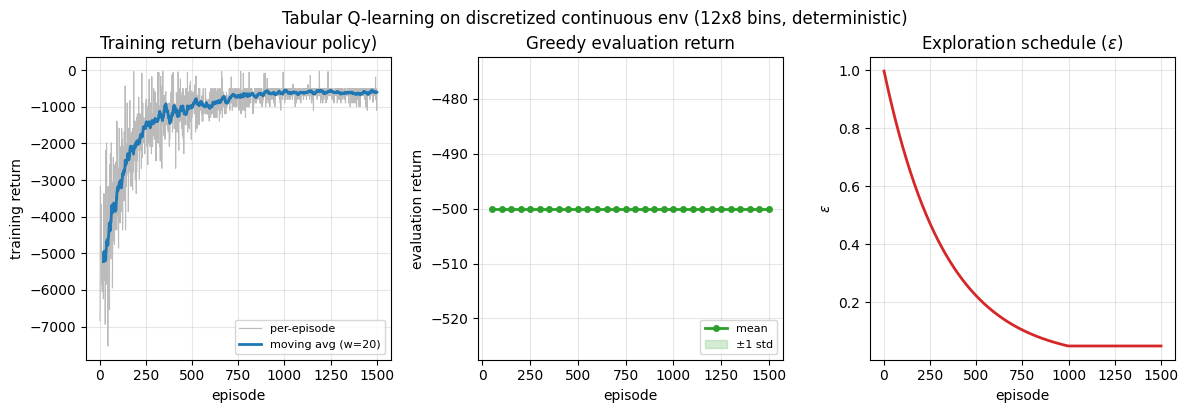

In [4]:
fig = plot_learning_curves(history)
fig.suptitle(
    f"Tabular Q-learning on discretized continuous env "
    f"({N_BINS_X}x{N_BINS_Y} bins, deterministic)", y=1.02
)
plt.show()

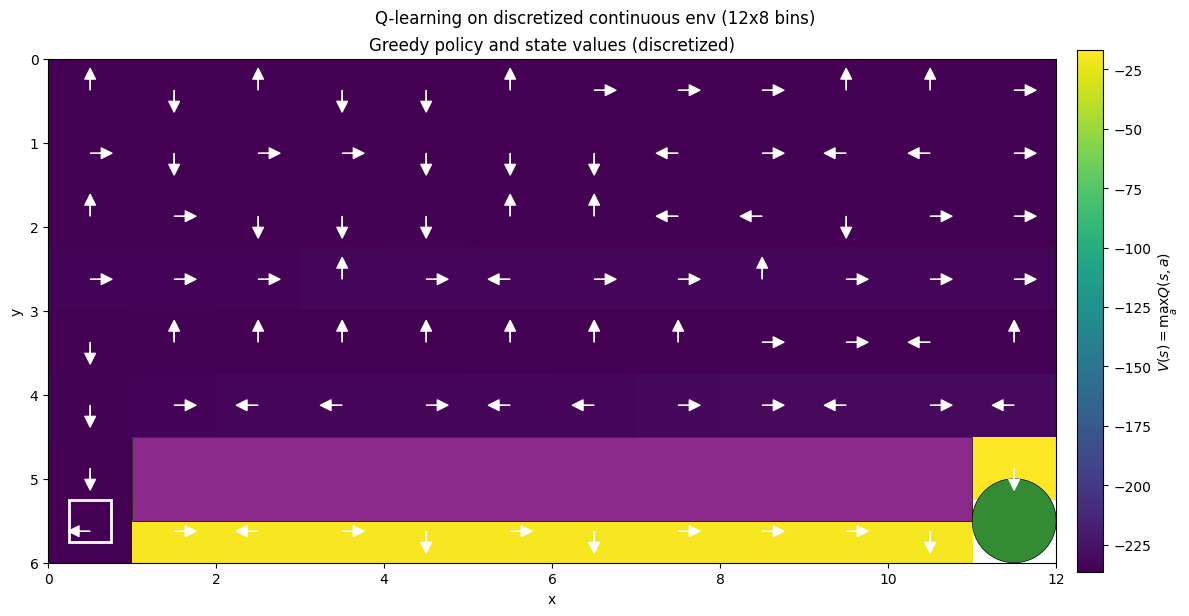

In [5]:
from rlc.utils.plotting import plot_discretized_policy

fig = plot_discretized_policy(
    agent, train_env, inner_env,
    annotate_values=False,
)
fig.suptitle(
    f"Q-learning on discretized continuous env ({N_BINS_X}x{N_BINS_Y} bins)",
    y=1.02
)
plt.show()

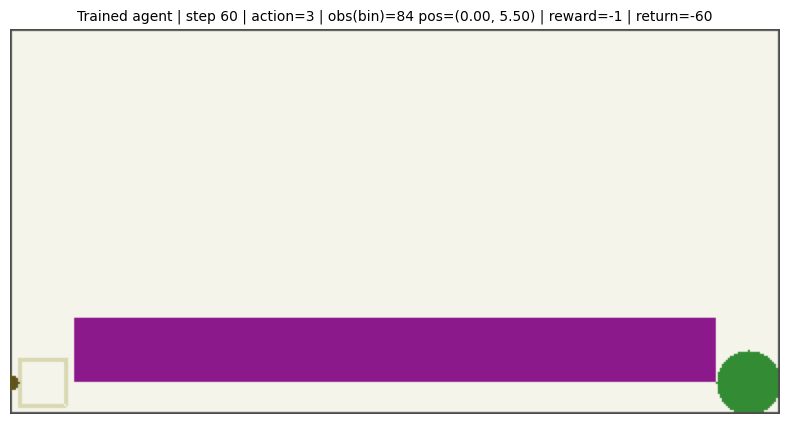

Episode ended after 60 steps with return -60.


In [6]:
def show_frame(frame, title):
    plt.figure(figsize=(10, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

FRAME_DELAY = 0.25
ROLLOUT_MAX_STEPS = 60

# We use the inner env directly for visualisation (it has rendering),
# but we let the agent observe the discretized index.
demo_env = ContinuousMicrobeEnv(render_mode="rgb_array")
demo_wrapped = DiscretizingWrapper(demo_env, n_bins_x=N_BINS_X, n_bins_y=N_BINS_Y)

obs, _ = demo_wrapped.reset(seed=MASTER_SEED + 100)
ep_step, ep_return = 0, 0.0
last_continuous = demo_env._agent_pos.copy()

show_frame(
    demo_env.render(),
    title=f"Trained agent | step 0 | obs(bin)={obs} pos=({last_continuous[0]:.2f}, {last_continuous[1]:.2f})"
)
time.sleep(FRAME_DELAY)

for _ in range(ROLLOUT_MAX_STEPS):
    action = agent.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, info = demo_wrapped.step(action)
    ep_step += 1
    ep_return += reward
    last_continuous = demo_env._agent_pos.copy()

    clear_output(wait=True)
    show_frame(
        demo_env.render(),
        title=(
            f"Trained agent | step {ep_step} | action={action} | "
            f"obs(bin)={obs} pos=({last_continuous[0]:.2f}, {last_continuous[1]:.2f}) | "
            f"reward={reward:.0f} | return={ep_return:.0f}"
        )
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        break

demo_env.close()
print(f"Episode ended after {ep_step} steps with return {ep_return:.0f}.")

## How does performance depend on the discretization?

The single experiment we just ran tells us that *one specific discretization* leaves Q-learning with a substantially suboptimal policy. It does not, by itself, tell us what would happen with a different bin count. The natural next question — *would a finer discretization simply solve the problem?* — deserves a direct answer.

We re-run the same experiment for a series of bin counts on the same dish and plot the final greedy evaluation return as a function of the bin size. Two things are worth looking for in the resulting curve. First, whether more bins always help, or whether the relationship is more subtle. Second, whether *any* discretization, however fine, achieves the optimal return (which on the deterministic dish is $-13$, corresponding to the shortest legal path of $13$ steps from start to goal). The answer to the second question is the most informative.

  0%|          | 0/10 [00:00<?, ?it/s]

   6x3  ( 18 states) bin=2.000  ratio=0.50  final return = -500.0
   8x4  ( 32 states) bin=1.500  ratio=0.67  final return = -500.0
  10x5  ( 50 states) bin=1.200  ratio=0.83  final return = -500.0
  12x6  ( 72 states) bin=1.000  ratio=1.00  final return = -500.0
  14x7  ( 98 states) bin=0.857  ratio=1.17  final return =  -15.0
  16x8  (128 states) bin=0.750  ratio=1.33  final return =  -15.0
  18x9  (162 states) bin=0.667  ratio=1.50  final return = -500.0
  20x10 (200 states) bin=0.600  ratio=1.67  final return =  -15.0
  24x12 (288 states) bin=0.500  ratio=2.00  final return = -500.0
  32x16 (512 states) bin=0.375  ratio=2.67  final return =  -12.0


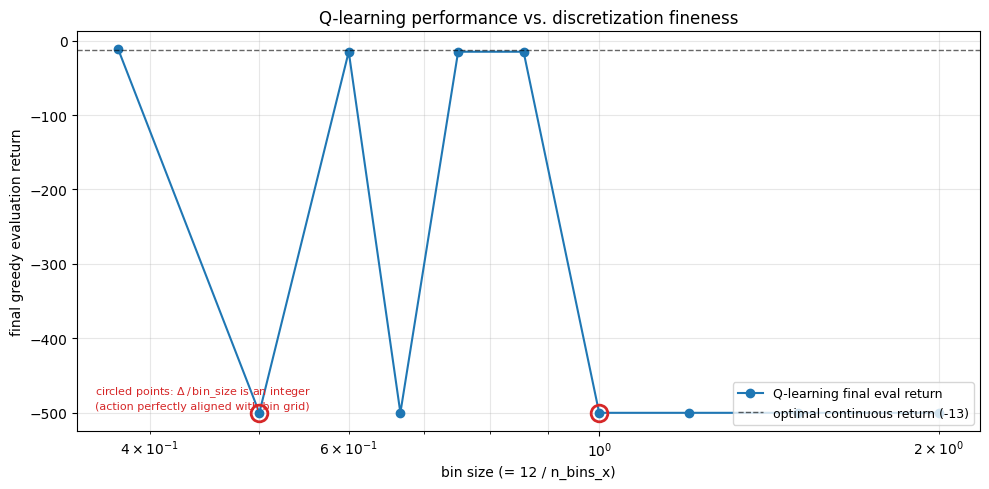

In [7]:
# Run Q-learning with several isotropic discretizations and collect the
# final greedy evaluation return for each.
from tqdm.notebook import tqdm

N_EPISODES = 500

bin_configs = [
    (6, 3), (8, 4), (10, 5), (12, 6), (14, 7),
    (16, 8), (18, 9), (20, 10), (24, 12), (32, 16),
]

# A short helper, ad hoc to this experiment.
def train_with_discretization(nx: int, ny: int) -> float:
    inner = ContinuousMicrobeEnv(render_mode=None)
    inner_eval = ContinuousMicrobeEnv(render_mode=None)
    train_env_loc = DiscretizingWrapper(inner, n_bins_x=nx, n_bins_y=ny)
    eval_env_loc = DiscretizingWrapper(inner_eval, n_bins_x=nx, n_bins_y=ny)
    agent_loc = QLearningAgent(
        n_states=train_env_loc.observation_space.n,
        n_actions=train_env_loc.action_space.n,
        seed=MASTER_SEED + 1,
        **Q_PARAMS,
    )
    hist_loc = train(
        agent_loc, train_env_loc,
        n_episodes=N_EPISODES,
        max_steps_per_episode=MAX_STEPS_PER_EPISODE,
        eval_every=N_EPISODES,            # only one eval at the end
        eval_episodes=EVAL_EPISODES,
        eval_env=eval_env_loc,
        eval_max_steps=EVAL_MAX_STEPS,
        seed=MASTER_SEED,
        progress=False,
    )
    return float(hist_loc.eval_mean_returns[-1])

# Run the sweep.
results = []
for (nx, ny) in tqdm(bin_configs):
    final_return = train_with_discretization(nx, ny)
    bin_size = 12.0 / nx
    ratio = 1.0 / bin_size  # displacement / bin_size
    results.append({
        "nx": nx, "ny": ny, "n_states": nx * ny,
        "bin_size": bin_size, "ratio": ratio,
        "final_return": final_return,
    })
    print(f"  {nx:>2}x{ny:<2} ({nx*ny:>3} states) "
          f"bin={bin_size:.3f}  ratio={ratio:.2f}  "
          f"final return = {final_return:6.1f}")

# Plot.
fig, ax = plt.subplots(figsize=(10, 5))

bin_sizes = [r["bin_size"] for r in results]
returns = [r["final_return"] for r in results]
ratios = [r["ratio"] for r in results]

ax.plot(bin_sizes, returns, "o-", color="#1f77b4", linewidth=1.5,
        markersize=6, label="Q-learning final eval return")

# Highlight aligned (integer-ratio) configurations.
for r, b, ret in zip(ratios, bin_sizes, returns):
    if abs(r - round(r)) < 1e-6:
        ax.plot(b, ret, "o", color="#d62728", markersize=12, mfc="none",
                markeredgewidth=2.0)

# Optimal return reference.
optimal_return = -13.0
ax.axhline(optimal_return, color="black", linestyle="--", linewidth=1.0,
           alpha=0.6, label=f"optimal continuous return ({optimal_return:.0f})")

ax.set_xscale("log")
ax.set_xlabel("bin size (= 12 / n_bins_x)")
ax.set_ylabel("final greedy evaluation return")
ax.set_title("Q-learning performance vs. discretization fineness")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="lower right", fontsize=9)

# Annotation for aligned configs.
ax.text(
    0.02, 0.05,
    "circled points: $\\Delta\\,/\\,\\mathrm{bin\\_size}$ is an integer\n"
    "(action perfectly aligned with bin grid)",
    transform=ax.transAxes, fontsize=8, color="#d62728",
    verticalalignment="bottom",
)

fig.tight_layout()
plt.show()

### What kind of problem is the agent actually solving?

It is worth pausing on a question we have not yet asked explicitly. The continuous environment we built defines a perfectly well-formed MDP: states are points in the plane, the transition kernel and reward function are deterministic, and the Markov property holds — the next state and reward depend only on the current state and action. When we wrap it with `DiscretizingWrapper`, we transform the observation. But what does this *do* to the MDP from the agent's point of view?

The honest answer is that the wrapped problem is no longer an MDP. It is a *Partially Observable Markov Decision Process*, or POMDP. The underlying state — the microbe's continuous position $(x, y)$ — still evolves deterministically and obeys the Markov property; what changes is that the agent does not observe it. It observes only the bin index, a coarse summary that *aliases* many distinct continuous states onto the same discrete observation. From the agent's perspective, identical observations can correspond to physically different situations, and identical observation-action pairs can therefore produce different next observations and rewards.

This is more than a technicality. It has three concrete consequences.

The first is that **the Markov property fails on the agent's observations**. Two episodes that bring the microbe to the same bin via different trajectories — leading to different exact continuous positions within that bin — produce, going forward, different distributions over future observations and rewards. The bin index alone is not a sufficient statistic for predicting the future. A *good* policy on a POMDP would, in principle, depend on the entire history of observations, not just on the current one; a Markov policy that maps each bin to a single action is forced to commit to one decision for all the within-bin states it cannot distinguish.

The second is that **Q-learning's convergence guarantees no longer apply** in the form we stated them. Tabular Q-learning converges to $q_\star$ on a finite MDP under the standard conditions; on a POMDP, those conditions are not satisfied, because the "state" the agent updates — the bin — is not a true Markov state. What Q-learning *does* converge to, in this setting, is the best Q-function that depends only on bin observations, which is in general not the optimal action-value function of the underlying problem. The gap between the two is exactly the loss the agent incurs by being unable to see the within-bin position.

The third is that **the noise in the agent's experience now has two sources**, rather than one. In the original `MicrobeGridEnv` of Lecture 1, the only stochasticity came from the `slippery` parameter; in the deterministic case, the same state-action pair always produced the same next state and reward. In the discretized continuous environment, even with $\sigma = 0$ in the underlying dynamics, the agent's observed transitions look stochastic: the same bin, the same action, can lead to different next bins because the within-bin starting position varies between visits. This *induced* stochasticity is not a property of the world but of the observation function, and it cannot be reduced by collecting more data — it is structural.

Putting these three together, what looks from the outside like "Q-learning solving a continuous problem with a discretized representation" is actually "Q-learning solving a POMDP that approximates the continuous problem". The approximation is good when the within-bin variation is small (fine bins) and when the action displacement aligns cleanly with the bin grid (no within-bin aliasing); it is poor otherwise. The next experiment quantifies how much it matters by sweeping over discretizations.

### Two regimes of policy failure

The bimodal shape of the sweep curve is not an accident of plotting; it reflects a real dichotomy in how a tabular agent can fail on a discretized continuous problem. Q-learning, after enough training, converges to a policy that falls into one of two qualitatively different regimes.

**Regime 1 — a readable path exists.** If the discretization is such that, at every bin along the route from start to goal, there is one action that is optimal *for most positions within that bin*, then Q-learning learns that action and the resulting policy successfully reaches the goal in a finite number of steps. The path may not be the optimal one — within-bin aliasing forces the agent to commit to a single action across positions that would individually prefer different ones, leading to small but real suboptimality — but the goal is reached, and the evaluation return is roughly $-\text{path length}$, between $-13$ and $-30$ on our dish.

**Regime 2 — no readable path exists.** If the discretization produces bins in which two distinct positions, both visited with comparable frequency, require *opposite* actions to make progress towards the goal, then the action that Q-learning averages across those positions is wrong for both of them. The microbe, executing this averaged action, enters a cycle or oscillates between bins. The greedy policy never reaches the goal. The evaluation return collapses to the value of `MAX_STEPS_PER_EPISODE` — in our setup, $-500$ — which corresponds not to a "moderately bad" policy but to a policy that does not terminate at all.

The transition between the two regimes is sharp because reaching the goal is a binary event: either the policy includes a finite path to it, or it does not. There is no natural intermediate behaviour, and so no natural intermediate value of the evaluation return. This is why the curve in the previous plot does not interpolate gracefully between a good and a bad configuration: it jumps.

# Value Function Approximation

The discretization experiments tell us something specific. The tabular representation cannot express the physical fact that nearby states are similar; refining the bins helps locally but does not address the structural problem; and the entire procedure of choosing a discretization is a workaround we should rather not have to perform. We need to change the *representation*, not the granularity.

### The strong idea

Replace the table $Q : \mathcal{S} \times \mathcal{A} \to \mathbb{R}$ by a **parametric function**. Instead of storing one number per state-action pair, we choose a family of functions $\hat{q}(s, a; \mathbf{w})$ controlled by a parameter vector $\mathbf{w} \in \mathbb{R}^d$, with $d$ much smaller than $|\mathcal{S}| \cdot |\mathcal{A}|$ (and finite even when the latter is infinite). Learning means adjusting $\mathbf{w}$ from experience, just as it meant adjusting the table entries before — but the gradient of one parameter affects, in general, the value of *all* state-action pairs, because the function is shared.

The structural payoff is **generalisation**. Updating $\hat{q}$ at one state pulls along the values at all states whose features overlap with the updated one. If the parametric family is well chosen, "states whose features overlap" coincides with "physically similar states", and the algorithm automatically does what tabular methods could not: it transfers knowledge from one state to its neighbours. The agent at bin $(7, 3)$ benefits from data collected at bin $(6, 3)$ without anyone having coded that the two bins are adjacent — the function approximator inherits this knowledge through the geometry of the feature map.

There is a price for this. Generalisation goes both ways: a parameter update that improves the value estimate at one state may *worsen* it at another state with overlapping features. The estimator is no longer a separate slot per state but a single object jointly fitted to all observed transitions, and the question of *what* is being optimised becomes substantive in a way it was not in the tabular case.

### How the agent changes

In the tabular setting the agent's update was a *direct assignment* to a single Q-table entry. In the function approximation setting, it becomes a *gradient-based adjustment* of the parameter vector that *induces* a change at the state of interest — and a residual change everywhere else.

Concretely, the canonical objective for prediction (evaluating a policy $\pi$) is the *mean squared value error*

$$\mathrm{MSVE}(\mathbf{w}) = \mathbb{E}_{s \sim \mu^\pi}\!\left[ \big(v^\pi(s) - \hat{v}(s; \mathbf{w})\big)^2 \right],$$

where $\mu^\pi$ is the on-policy state distribution. Stochastic gradient descent on this loss gives the parameter update

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \big(v^\pi(S_t) - \hat{v}(S_t; \mathbf{w})\big) \, \nabla_{\mathbf{w}} \hat{v}(S_t; \mathbf{w}),$$

which is the natural generalisation of the tabular update: in place of "increment the entry at $S_t$ by $\alpha (v^\pi(S_t) - V(S_t))$", we move the parameters along the gradient of $\hat{v}(S_t; \mathbf{w})$ by the same scaled error. In the tabular limit, where $\hat{v}(s; \mathbf{w}) = w_s$ and $\nabla_{\mathbf{w}} \hat{v}(s; \mathbf{w})$ is a one-hot vector at index $s$, this update reduces *exactly* to the tabular one — confirming that the function approximation framework contains the tabular setting as a special case, rather than replacing it.

Of course, $v^\pi(S_t)$ is unknown — it is what we are trying to estimate. As in the tabular case, we replace it with a *target*: the Monte Carlo return $G_t$ (unbiased, high variance), or the TD target $R_{t+1} + \gamma \hat{v}(S_{t+1}; \mathbf{w})$ (biased, low variance), exactly the same dichotomy we discussed in Lecture 2. The two choices give *Monte Carlo prediction with function approximation* and *TD prediction with function approximation* respectively, and they are the basis of every prediction algorithm in the rest of this course. We will focus on the TD version today.

The action selection logic — $\varepsilon$-greedy with respect to $\hat{q}$ — is mechanically identical to the tabular case: the only difference is that "look up the Q-values for state $s$" now means "evaluate $\hat{q}(s, a; \mathbf{w})$ for each action $a$" instead of "read the row of the Q-table at index $s$". From the agent's point of view, nothing else changes. The training loop, the evaluation protocol, the visit counters, the plotting helpers — all of these survive unchanged.

### Limits of the approach

Three limitations are worth being aware of from the start, because they will shape the rest of L3 and especially L4.

**The choice of feature map matters, and it is not done by the algorithm.** In the linear case $\hat{v}(s; \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$, the feature vector $\mathbf{x}(s) \in \mathbb{R}^d$ is *given*, not learned. Different feature maps produce different generalisation patterns: tile coding and radial basis functions, which we will see in detail next, generalise locally; polynomial features generalise globally; coordinate-only features ($\mathbf{x}(s) = s$) generalise linearly along each axis. Choosing a poor feature map is the new failure mode that replaces "choosing a poor discretization" — it is not solved automatically, and the difference between a useful agent and a useless one is often hidden in this choice. In Lecture 5 we will see how deep neural networks address this concern by *learning* the features along with the value function; until then, feature engineering is an explicit design step.

**The estimator is no longer exact.** A tabular Q-table can represent any function on a finite state space exactly, given enough data. A linear approximator restricted to features $\mathbf{x}(s)$ can only represent functions in the column space of those features; the optimal $v^\pi$ may simply not be in that space. The best the approximator can do is the *projection* of $v^\pi$ onto the representable space — which depends on the features, on the on-policy distribution $\mu^\pi$, and on the geometry of the feature map. This projection error is a property of the representation, not a learning artefact, and no amount of additional training reduces it.

**With bootstrapping, we are not even minimising what we appear to minimise.** If we replace $v^\pi(S_t)$ with the TD target $R_{t+1} + \gamma \hat{v}(S_{t+1}; \mathbf{w})$ and follow what looks like the gradient of the resulting squared error, we are *not* in fact computing a true gradient. The TD target depends on $\mathbf{w}$ as well — through $\hat{v}(S_{t+1}; \mathbf{w})$ — but conventional TD with function approximation ignores that dependence in the gradient computation. The resulting update is called a *semi-gradient*, and it is the subject of the final section of this lecture. The semi-gradient is not just a notational quibble: in some configurations it can fail to converge entirely, even on perfectly well-posed problems, in ways that the tabular case never showed. We will see why this is in Lecture 4 when we discuss the *deadly triad*; today we set the stage by deriving the semi-gradient TD(0) update and observing it work — for now — on our problem.

The next section turns to the most concrete instantiation of all this: linear feature maps, applied to `ContinuousMicrobeEnv`.

## Why a state function?
We define VFA by conceiving the state as a function $\mathbf{x}(s)$. But why not simply $\mathbf{x}(s) = s$?

### Why features at all?

The function approximation framework gives us a parametric model $\hat{v}(s; \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$, where the feature map $\mathbf{x}(\cdot)$ is given. The natural first question is the laziest possible one: *why not let $\mathbf{x}(s) = s$?* The state is already a vector — the position $(x, y)$ on the dish — and feeding it directly into a linear combination is the most economical thing we could do.

The answer is that this would not work, and seeing why is the cleanest way to understand what features actually buy us.

If we set $\mathbf{x}(s) = s = (x, y)^\top$, the model becomes $\hat{v}(s; \mathbf{w}) = w_1 x + w_2 y + b$ for some weights $w_1, w_2$ and bias $b$. This is a *plane* in the $(x, y)$ space. A plane has exactly two degrees of freedom for the slope and one for the height — three numbers in total — and it can only represent value functions that increase or decrease linearly in each direction. The true $V^\pi(s)$ of our microbe problem is nothing of the sort: it has a low region near the goal, a high region near the start, a discontinuous drop above the toxic band, and curvature everywhere. No plane can fit it.

This is a question of *representational capacity*, and it has nothing to do with how good our learning algorithm is. With $\mathbf{x}(s) = s$, even an oracle that magically gave us the optimal weights $\mathbf{w}^\star$ would only produce the *best plane that approximates $V^\pi$* — typically not very good. The error between this best plane and the true $V^\pi$ is the *projection error* we mentioned in the previous section, and increasing the training budget cannot reduce it. The agent is fundamentally stuck.

The way out is to expand $\mathbf{x}(s)$ beyond the bare state, transforming it into a richer vector of derived quantities. This is the **essential trick of linear function approximation: *we move the non-linearity into the features, while keeping the model linear in the weights*.** The feature map $\mathbf{x}(\cdot)$ can be as non-linear as we want — quadratic, exponential, indicator-valued, anything — and the resulting $\mathbf{w}^\top \mathbf{x}(s)$ inherits all of that non-linearity in $s$. The crucial property is that learning $\mathbf{w}$ remains a *linear* problem: convex, with closed-form solutions in the prediction case, gradient-based but well-understood with bootstrapping. The non-linearity is paid for in the feature design, once, and the benefit accrues to every subsequent training step.

The same idea underlies polynomial regression in supervised learning, kernel methods in support vector machines, and (loosely) the embedding layers of modern deep models. In each case the question becomes *which* feature map to choose. We will see two classical choices today, suited to continuous low-dimensional state spaces.

### Tile coding

Tile coding partitions the state space into one or several offset rectangular grids — *tilings* — each of size $n_x \times n_y$. For a given state, exactly one tile is active per tiling, and the feature vector concatenates the resulting one-hot indicators across tilings. With one tiling, this is binary discretization. With $T > 1$ tilings, each state activates $T$ features — one per tiling — and *neighbouring* states share some of these activations while differing on others. The overlap pattern is what enables generalisation: a weight update at a state pushes the values at all states sharing one of its active tiles, and the magnitude of the push decays with the number of shared tiles, which decays with distance.

Three parameters define a tile coding scheme: the resolution per axis ($n_x$, $n_y$), and the number of tilings ($T$). The total feature dimension is $T \cdot n_x \cdot n_y$, but on any given state only $T$ of these are non-zero — the encoding is *sparse*. Sparsity is computationally convenient: an update modifies only $T$ weights per step, regardless of total dimension. The locally-constant nature of each tile means the resulting value function is piecewise constant on each tiling, with smoothness arising only from the superposition of multiple offsetted tilings.

Tile coding is the workhorse of tabular-style RL with continuous states, and a default starting point in the field. Its strengths are sparsity (fast updates, no dense linear algebra), interpretability (each weight corresponds to a specific tile), and robustness (it just works on a wide range of problems). Its weaknesses are that it is *not* differentiable in the state and that the choice of resolution is, again, a hyperparameter without a canonical answer.

### Radial basis functions

Radial basis functions go in the opposite direction. A regular grid of $n_x \times n_y$ centres is placed in the state space, and each feature is a Gaussian "bump" evaluated at the state — large when the state is near the centre, exponentially decaying with distance. The feature vector is *dense*: every feature is non-zero on every state, although most are very small far from their centre.

Two parameters control the encoding: the number of centres and the bandwidth $\sigma$ of the Gaussians. Bandwidth is the more interesting of the two. With $\sigma$ small relative to the spacing between centres, each feature is sharply localised and the encoding behaves locally — close to a "soft tile coding". With $\sigma$ large relative to the spacing, neighbouring features overlap heavily and the encoding behaves globally — close to a smooth interpolation. Tuning $\sigma$ effectively interpolates between two qualitatively different behaviours of the same family.

RBF features are smooth in the state, which means the resulting value function $\hat{v}(s; \mathbf{w})$ is a smooth function of position — it has well-defined gradients everywhere, suitable for downstream methods that require differentiability. They are dense, which means every update touches *every* weight (computationally heavier than tile coding for the same resolution). And they are compositional: a sum of Gaussians can approximate, in the limit of many centres and well-chosen widths, any sufficiently smooth function — a property formalised in functional analysis but useful even informally.

### What we will look at

The next code cell instantiates one tile coder and one RBF extractor, both spanning the dish, and visualises a small subset of their features as heatmaps over the state space. The pictures will make concrete what the two paragraphs above said in words: the locally-constant, indicator-valued nature of tile coding, and the smooth, dense, Gaussian-bump nature of RBFs. After looking at them we will train a linear Q-learning agent on each, and observe how the choice of feature map shapes what the agent can learn.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from rlc.utils.features import TileCoder, RBFFeatures

# Bounds of the Petri dish.
LOW = np.array([0.0, 0.0])
HIGH = np.array([12.0, 6.0])

# Two feature extractors with comparable but distinct configurations.
tile_coder = TileCoder(
    low=LOW, high=HIGH,
    n_tiles_x=10, n_tiles_y=5,
    n_tilings=4,
    seed=0,
)

rbf_features = RBFFeatures(
    low=LOW, high=HIGH,
    n_centers_x=10, n_centers_y=5,
    sigma=0.6,
    normalize=False,
)

print(f"TileCoder:    n_tiles=10x5, n_tilings=4 -> n_features = {tile_coder.n_features}")
print(f"  tile size: {tile_coder.tile_size_x:.2f} x {tile_coder.tile_size_y:.2f}")
print(f"  active features per state: {tile_coder.n_tilings} (sparse)")

print(f"RBFFeatures:  n_centers=10x5, sigma=0.6 -> n_features = {rbf_features.n_features}")
print(f"  active features per state: {rbf_features.n_features} (dense)")

TileCoder:    n_tiles=10x5, n_tilings=4 -> n_features = 200
  tile size: 1.20 x 1.20
  active features per state: 4 (sparse)
RBFFeatures:  n_centers=10x5, sigma=0.6 -> n_features = 50
  active features per state: 50 (dense)


### Visualizing single features

Each feature is a function from the dish to $\mathbb{R}$ — a scalar that takes a value at every point in $\mathcal{S}$. The most direct way to *see* a feature is to evaluate it on a fine grid of states, paint the resulting values as a heatmap, and look at the shape of the region where the feature is "active". A small selection of features per kernel is enough to make the differences between the two families visible.

We pick four features from each extractor, chosen at evenly-spaced positions across the dish, and plot each as its own panel. For tile coding we sample features from a single tiling so that the indicator nature is unmistakable; for RBFs we plot the Gaussian centred at the corresponding grid point. The result is two side-by-side rows, one per kernel.

A short clarification on terminology before we look at the pictures. In tile coding, a *tile* is simply a rectangular region of the state space. A *tiling* is a partition of the entire state space into tiles that together cover everything without overlapping — like the tiles of a floor in a real room. *Multiple tilings* are several such coverings, layered on top of each other and slightly offset so that the tile boundaries of one tiling never coincide exactly with those of another. A state always falls into exactly one tile per tiling, and into as many tiles as there are tilings. Tile coding's features are binary indicators of *which* tile of *which* tiling a state lies in.

With this language in place, we can now make sense of what to look at. Each feature is a function from the dish to $\mathbb{R}$ — a scalar that takes a value at every point in $\mathcal{S}$. The most direct way to *see* a feature is to evaluate it on a fine grid of states, paint the resulting values as a heatmap, and look at the shape of the region where the feature is "active". A small selection of features per kernel is enough to make the differences between the two families visible.

We pick four features from each extractor, chosen at evenly-spaced positions across the dish, and plot each as its own panel. For tile coding we sample features from a single tiling so that the indicator nature is unmistakable; for RBFs we plot the Gaussian centred at the corresponding grid point. The result is two side-by-side rows, one per kernel.

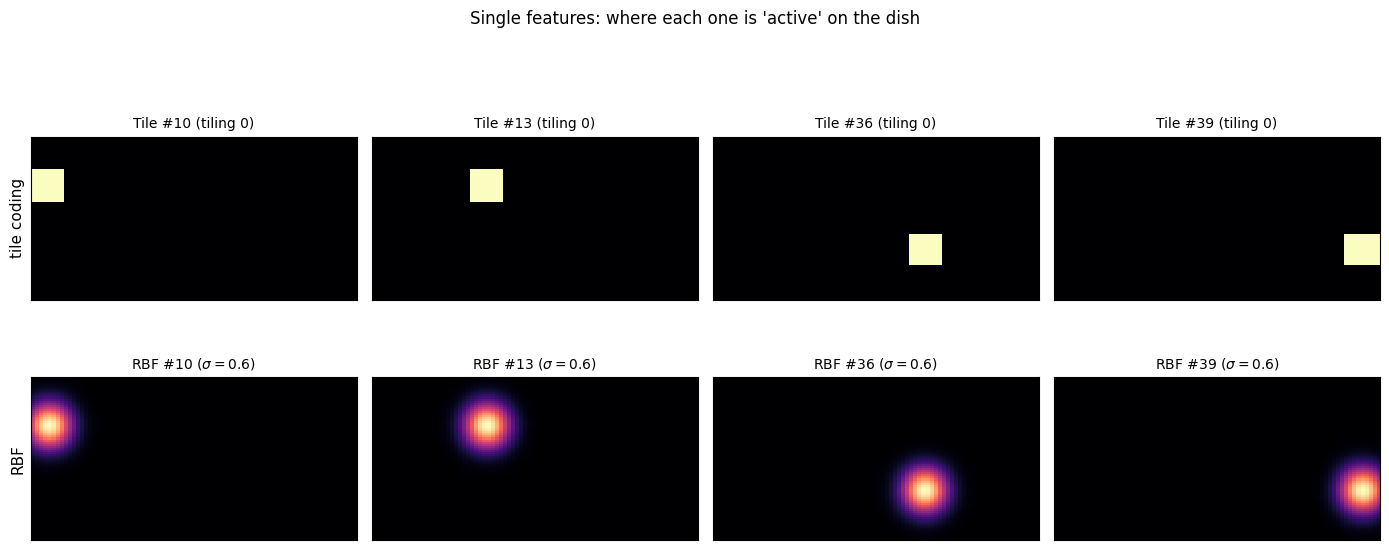

In [9]:
# Build a fine evaluation grid covering the dish.
N_EVAL = 80
xs = np.linspace(LOW[0], HIGH[0], N_EVAL)
ys = np.linspace(LOW[1], HIGH[1], N_EVAL)
XX, YY = np.meshgrid(xs, ys)
grid_states = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (N_EVAL**2, 2)

# Evaluate each extractor on the grid.
def evaluate_on_grid(extractor):
    feats = np.array([extractor(s) for s in grid_states])  # (N_EVAL**2, n_features)
    return feats.reshape(N_EVAL, N_EVAL, -1)

tile_grid = evaluate_on_grid(tile_coder)
rbf_grid = evaluate_on_grid(rbf_features)

# Pick four features at well-spread positions in the dish.
# For tile coding: features from tiling 0, at the indicated (col, row) of
# the tiling grid. With n_tiles_x=10, n_tiles_y=5, tile (col, row) has
# index col + row * n_tiles_x = col + 10 * row inside that tiling's block.
tile_indices = [
    0 + 10 * 1,          # col 0, row 1 (left, mid-upper)
    3 + 10 * 1,          # col 3, row 1
    6 + 10 * 3,          # col 6, row 3
    9 + 10 * 3,          # col 9, row 3 (right, mid-lower)
]

# For RBFs: centres at the same logical positions on the 10x5 grid.
# RBF centres are stored row-major: index = row * n_centers_x + col.
rbf_indices = [
    0 + 10 * 1,
    3 + 10 * 1,
    6 + 10 * 3,
    9 + 10 * 3,
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)

for j, idx in enumerate(tile_indices):
    ax = axes[0, j]
    img = tile_grid[:, :, idx]
    ax.imshow(img, origin="upper", extent=(LOW[0], HIGH[0], HIGH[1], LOW[1]),
              cmap="magma", vmin=0, vmax=1, interpolation="nearest", aspect="equal")
    ax.set_title(f"Tile #{idx} (tiling 0)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

for j, idx in enumerate(rbf_indices):
    ax = axes[1, j]
    img = rbf_grid[:, :, idx]
    ax.imshow(img, origin="upper", extent=(LOW[0], HIGH[0], HIGH[1], LOW[1]),
              cmap="magma", vmin=0, vmax=1, interpolation="nearest", aspect="equal")
    ax.set_title(f"RBF #{idx} ($\\sigma=0.6$)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].set_ylabel("tile coding", fontsize=11)
axes[1, 0].set_ylabel("RBF", fontsize=11)
fig.suptitle("Single features: where each one is 'active' on the dish",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

The two rows tell the story of the two kernels concisely.

The **tile coding row** shows four sharp rectangular regions. Each feature is a binary indicator: it takes value $1$ inside its tile and $0$ everywhere else, with no transition zone in between. The state-space "patches" are crisp; a state belongs to exactly one tile per tiling, with no ambiguity about its membership and no soft falloff at the boundaries. With $4$ tilings simultaneously active in our configuration, the actual feature representation of any state is the union of *four* such crisp regions, each from a different tiling; we are seeing only one of those tilings here.

The **RBF row** shows four soft Gaussian bumps. Each feature is a continuous function of the state, peaking at its centre and decaying smoothly to (very small but) non-zero values everywhere else on the dish. There is no sharp boundary: a state slightly off-centre still activates the feature substantially, and a state at the opposite side of the dish activates it almost imperceptibly. The standard deviation $\sigma = 0.6$ controls how wide the bumps are — visibly comparable in scale to a single tile of the tile coder, but with smooth rather than discrete transitions.

The qualitative difference is clear, but the consequence for learning is what really matters. Two states that fall in the *same* tile of the tile coder are, from the agent's point of view, indistinguishable on that tiling: their tile coding features are identical, and the linear approximator must assign them the same value contribution from that tiling. Two states that fall in *adjacent* tiles share zero tile coding features on that tiling: their value contributions from that tiling are completely independent. The transition is binary.

For RBFs there is no such transition. Two states close to a centre have nearly identical activations of that feature; two states far from the centre have nearly identical (small) activations. The encoding interpolates continuously between the two extremes. Adjacent regions of the state space do not need a special "tilings" trick to be linked — they are linked automatically by the continuous nature of the kernel.

This first picture is suggestive but incomplete. What we still cannot see is *what the entire feature representation does to a state* — the tile coding answer is "activates one feature per tiling, all of them similarly far from each other"; the RBF answer is "activates many features, with weights that decay with distance to centres". The next visualisation makes this explicit.

### Three states, three representations

The single-feature heatmaps showed where each individual feature is "active" on the dish. They tell us what one feature does, but not what the entire feature representation does to a state. The cleanest way to ask the latter is to fix a few specific states and look at how their pairwise distances change as we go from the raw state to its tile-coded representation, and then to its RBF representation.

We pick three states on the dish: two close to each other, $s_A$ and $s_B$, and a third one far from both, $s_C$. In the raw state space the pairwise distances are unambiguous — close states have small Euclidean distance, far states have large Euclidean distance. We then ask the same question in feature space: *what is the Euclidean distance between $\mathbf{x}(s_A)$ and $\mathbf{x}(s_B)$?* And between $\mathbf{x}(s_A)$ and $\mathbf{x}(s_C)$? The answers tell us, concretely, what the feature representation considers "close" and "far".

Because the feature vectors of the two extractors live in spaces of different dimensions and with different scales (a tile-coded vector has length $\sqrt{n_{\text{tilings}}}$, an RBF vector has a different scale altogether), comparing the absolute distances between representations is not informative. What is informative is the *ratio* between distances within each representation: how much further is $s_C$ from $s_A$, compared to how far $s_B$ is. We will normalize the three distances per representation by the largest among them, and look at the resulting profiles side by side.

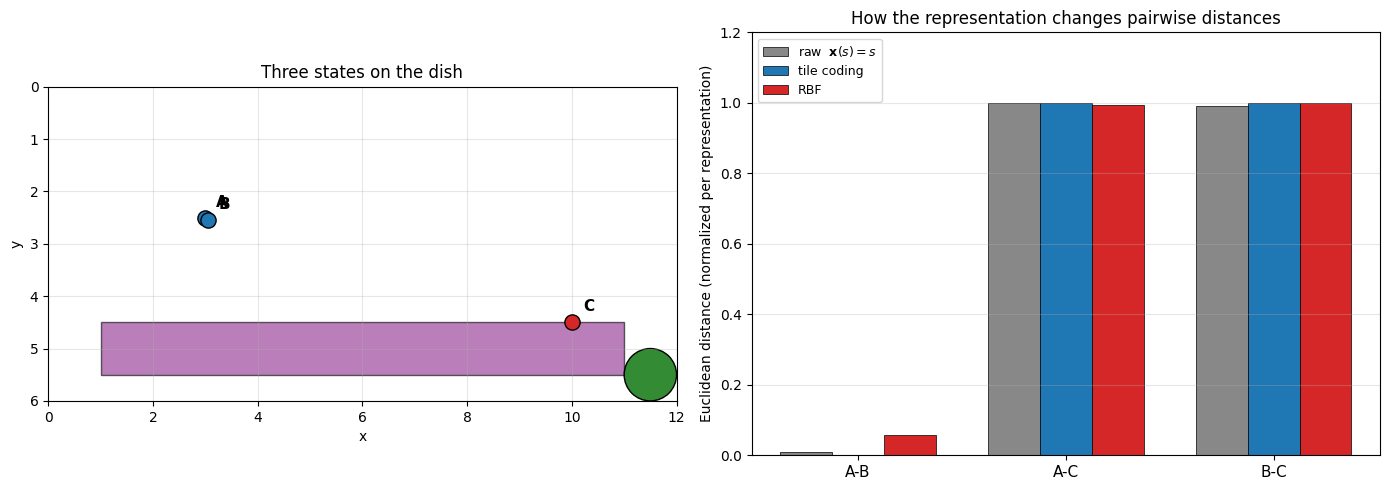


Unnormalized Euclidean distances:
  pair   raw  $\mathbf{x}(s)=s$             tile coding                     RBF
  A-B                     0.0707                  0.0000                  0.0748
  A-C                     7.2801                  2.8284                  1.2789
  B-C                     7.2184                  2.8284                  1.2870


In [10]:
# Three states: A and B close to each other (within one tile of the tile coder),
# C far from both, near the goal-toxic interface.
s_A = np.array([3.0, 2.5])
s_B = np.array([3.05, 2.55])
s_C = np.array([10.0, 4.5])

states = {"A": s_A, "B": s_B, "C": s_C}
pairs = [("A", "B"), ("A", "C"), ("B", "C")]

# Three representations of each state.
def raw(s): return s.copy()

reps = {
    "raw  $\\mathbf{x}(s)=s$": raw,
    "tile coding":              tile_coder,
    "RBF":                      rbf_features,
}

# Compute pairwise Euclidean distances in each representation.
distances = {}
for name, fn in reps.items():
    feats = {k: fn(v) for k, v in states.items()}
    distances[name] = {
        f"{a}-{b}": float(np.linalg.norm(feats[a] - feats[b]))
        for (a, b) in pairs
    }

# Plot two panels side by side: dish with the three states, and a bar chart
# of normalised distances grouped by representation.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: the three states on the dish ---
ax = axes[0]
# Toxic rectangle.
ax.add_patch(plt.Rectangle((1.0, 4.5), 10.0, 1.0,
                           facecolor="#8c2a8c", edgecolor="black", alpha=0.6))
# Goal disc.
ax.add_patch(plt.Circle((11.5, 5.5), 0.5,
                        facecolor="#338c33", edgecolor="black"))
# Three states.
colors = {"A": "#1f77b4", "B": "#1f77b4", "C": "#d62728"}
for name, s in states.items():
    ax.scatter(s[0], s[1], c=colors[name], s=120, zorder=3,
               edgecolors="black", linewidths=1.0)
    ax.annotate(name, (s[0], s[1]), textcoords="offset points",
                xytext=(8, 8), fontsize=11, fontweight="bold")

ax.set_xlim(0, 12); ax.set_ylim(6, 0)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Three states on the dish")
ax.grid(alpha=0.3)

# --- Panel 2: normalised distances per representation ---
ax = axes[1]
n_pairs = len(pairs)
n_reps = len(reps)
bar_width = 0.25
x_positions = np.arange(n_pairs)

bar_colors = ["#888888", "#1f77b4", "#d62728"]
for i, (rep_name, dists) in enumerate(distances.items()):
    values = np.array([dists[f"{a}-{b}"] for (a, b) in pairs], dtype=np.float64)
    # Normalize by the max within this representation.
    if values.max() > 0:
        values = values / values.max()
    ax.bar(x_positions + (i - 1) * bar_width, values, bar_width,
           label=rep_name, color=bar_colors[i], edgecolor="black", linewidth=0.5)

ax.set_xticks(x_positions)
ax.set_xticklabels([f"{a}-{b}" for (a, b) in pairs], fontsize=11)
ax.set_ylabel("Euclidean distance (normalized per representation)")
ax.set_title("How the representation changes pairwise distances")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0, 1.2)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

# Print raw numbers for reference.
print("\nUnnormalized Euclidean distances:")
print(f"  {'pair':<6}", "  ".join(f"{name:>22}" for name in reps))
for (a, b) in pairs:
    row = f"  {a}-{b:<4}"
    for name in reps:
        row += f"  {distances[name][f'{a}-{b}']:>22.4f}"
    print(row)

The three bar groups tell three different stories.

**Raw representation $\mathbf{x}(s) = s$.** Distance $A$-$B$ is small, distances $A$-$C$ and $B$-$C$ are large and approximately equal. This matches our intuition: $A$ and $B$ are physically close, $C$ is far from both. The feature space *is* the state space, so distances are just physical distances. Any model linear in this representation can only express linear functions of position: a plane on the dish.

**Tile coding.** Distance $A$-$B$ is *zero* — or close to it. The two states fall in the same tile of the tile coder (verify it by looking at their coordinates against the tile size of $1.2 \times 1.2$); their tile-coded feature vectors are identical, indistinguishable from the agent's perspective on whichever tilings have them in the same tile. Distances $A$-$C$ and $B$-$C$ are at the maximum of the representation: the two pairs share *no* active tile, so their feature vectors are orthogonal, and the agent treats them as completely unrelated. Tile coding produces a *clipped* notion of similarity: states inside the same tile are perfectly equivalent; states in different tiles are perfectly distinct. Generalisation is binary, and the tile resolution sets the scale at which the binary cutoff occurs.

**RBF.** Distance $A$-$B$ is small — but not zero. RBFs do not collapse close states into a single point; they smoothly decrease the feature-space distance as the state-space distance shrinks, but never to zero unless the states coincide exactly. Distances $A$-$C$ and $B$-$C$ are large but slightly different from each other, because the Gaussian centres are positioned differently relative to $C$, $A$, and $B$. RBFs produce a *gradual* notion of similarity, with $\sigma$ controlling the scale at which similarity decays.

The right panel makes the central claim of feature engineering visible: *the same three states have entirely different similarity structures in the three representations*. A learning algorithm that operates on the raw state will treat $A$, $B$, $C$ as configured by their physical distances. A learning algorithm operating on tile-coded features will treat $A$ and $B$ as exactly the same state, and $C$ as a wholly separate one. A learning algorithm operating on RBF features will treat $A$ and $B$ as similar but distinct, and $C$ as far from both.

This is the lever that turns the linear approximator into something useful. By choosing how we measure similarity at the feature level, we control how information learned at one state will propagate to other states during training. Tile coding chooses a *coarse, sharp* propagation; RBFs choose a *smooth, soft* one; the raw state chooses a *uniform, linear-only* propagation that is, as we noted at the start, almost always too rigid for a non-trivial value function.

We have now built the conceptual scaffolding to introduce the actual learning algorithm. We know what features are and what they do; the next section formalises the update rule that moves the linear weights $\mathbf{w}$ in response to observed transitions, and surfaces the subtle but crucial property that gives the family its full name — *semi-gradient* TD methods.

### Two natural questions before we move on

Two questions arise at this point, both worth answering carefully because they clarify exactly what tile coding and RBFs are and what they are not.

**Question one. What is the difference between tile coding and the discretization we used at the beginning of the lecture?**

The two are operationally similar but fundamentally distinct in what they represent and how they generalise.

The discretization used in `DiscretizingWrapper` returned, for each continuous state, a *single integer* — the index of the bin the state fell into. The agent's observation space became `Discrete`, the agent maintained a *table* indexed by this integer, and the only thing the agent could learn for a given bin was a single scalar value, applicable uniformly to every continuous state inside that bin. There was no notion of similarity *between* bins: two adjacent bins were two different integer indices, and what the agent learned at one was unrelated to what it learned at the other.

Tile coding returns, for each continuous state, a *binary feature vector* of dimension $T \cdot n_x \cdot n_y$ — much larger than a single integer. The agent maintains a *weight vector* of the same dimension, and the value of a state is computed as a *linear combination* of the active features. With a *single tiling*, this is mathematically equivalent to the discretization: each state activates exactly one feature, the corresponding weight is the value, and the encoding is just a one-hot version of the bin index. With *multiple tilings*, this equivalence breaks: each state activates several features, the value is the sum of several weights, and a weight update at one state pulls along the values of all states sharing one of its active features. Generalisation arises automatically from the overlap between tilings, and learning at one continuous position transfers — partially, with the right geometry — to nearby positions.

So: the tile coder we used in the visualisation just now (with a single tiling, for clarity of the picture) is operationally equivalent to a discretization, and indeed produces the same binary "same tile" similarity. The tile coder we will use for actual training has multiple tilings and is something *more*: a smoothed-out generalisation of discretization that retains its sparsity and computational simplicity but recovers the ability to share information between nearby states. Discretization is the degenerate case of tile coding with $T = 1$.

**Question two. The state is just $(x, y)$. Why not use a polynomial expansion — terms like $x$, $y$, $xy$, $x^2$, $y^2$ and so on — instead of tile coding or RBFs?**

Polynomial features are a perfectly valid choice in linear function approximation, and on certain kinds of problems they are excellent. The reason we do not use them here is that the value functions arising in our problem have *local* structure that polynomial features struggle to capture.

Polynomial features are *global*: a single weight on the term $x^2$ influences the value of $\hat{v}(s)$ at *every* state on the dish. An update that improves the value estimate near $(3, 2)$ will inevitably modify the value estimate near $(10, 5)$, even if the two regions are physically and dynamically unrelated. The geometry of polynomial features privileges global, smooth variation over local detail.

The value functions of our microbe problem are not globally smooth. They have a sharp drop at the toxic boundary, a localised plateau near the goal, a slow ramp through the upper rows of the dish — features that change character abruptly across regions. A polynomial of degree $d$ can represent only a $d$-th order polynomial surface; capturing the toxic discontinuity faithfully requires $d$ to grow large, and as $d$ grows the polynomial becomes both more numerically delicate and more prone to oscillations elsewhere on the dish. Polynomial features are a poor match for problems with localised structure.

Tile coding and RBFs are *local* by design. A tile-coded weight only contributes to states inside its tile (and, with multiple tilings, to nearby states whose other tilings still share that tile); an RBF weight only contributes substantially to states near its centre. Local features mean local learning: an update in one region adjusts values primarily there, leaving the rest of the dish alone. For value functions with localised structure — almost all interesting RL problems — locality is the right inductive bias.

This does not make polynomials wrong. They are appropriate for problems with globally smooth value functions and few discontinuities. But they would be a poor first introduction to function approximation in RL, because most RL problems exhibit precisely the kind of local structure that polynomials fail to capture. Tile coding and RBFs are the canonical choices in the field for this reason.

There is also a deeper observation. In Lecture 5 we will replace hand-designed feature maps entirely with neural networks, which *learn* their features from data. The choice between local and global representations no longer needs to be made at design time, because the network adapts its features to the problem. But this comes at the cost of needing more data, more computation, and a less transparent picture of what is being represented. The hand-designed local features we are looking at today are, in a sense, the simplest non-trivial answer to the function approximation problem; they encode the inductive bias that nearby states matter together, without requiring us to learn it.


### Local versus global feature maps: a geometric reading

The two questions answered above converge on a single geometric distinction. **Tile coding and RBFs are *local* feature maps**: each individual feature is sensitive only to a small region of the state space, and the feature vector $\mathbf{x}(s)$ of a state describes a *neighbourhood* — which tile it belongs to, which centres it is near. Two states whose neighbourhoods overlap have similar feature vectors; two states whose neighbourhoods are disjoint have feature vectors that are essentially orthogonal. The geometry of feature space mirrors, faithfully and locally, the geometry of state space.

**Polynomial features and other *global* maps work differently**. Each feature is a function of the entire state, with no privileged region: a polynomial like $xy$ takes substantial values across most of the dish, and a single weight on it influences $\hat{v}$ everywhere. The geometry of feature space, in this case, can radically reshape the geometry of state space: two physically distant states can map to similar feature vectors if their global characterisation happens to coincide, and two physically nearby states can map to very different feature vectors if their global signatures differ. Global maps trade locality for expressive flexibility — they can encode similarities that have nothing to do with physical proximity, but they cannot encode physical proximity itself without effort.

For our microbe problem, **locality is the right inductive bias**. The dynamics are local — an action moves the microbe by a small displacement, never teleports it across the dish (except after a toxic visit, which is a separate event the agent learns about explicitly). The reward structure is local — toxic regions and goals are bounded subsets of the dish. The value function inherits this locality — what happens at one point on the dish depends primarily on what surrounds that point, not on the global configuration of the entire state space. A representation that respects this structure makes learning *easier*: the agent does not have to discover that "nearby states matter together", because the feature map already encodes it. The cost of generalising knowledge from one state to another is paid for by the geometry of $\mathbf{x}(\cdot)$, not by additional samples.

Choosing local features is therefore not a methodological default but a substantive commitment. We are telling the algorithm that the value function we are trying to learn varies smoothly in space and that nearby states should be treated as similar. The tile coder and the RBF extractor encode this commitment in two different ways — sharply, with overlapping tilings, in the first case; smoothly, with Gaussian neighbourhoods, in the second — but the underlying inductive bias is the same. Whether tile coding or RBFs is the better choice for a given problem depends on whether the value function is more naturally piecewise constant or smooth, and on which features are more convenient to compute and tune; we will see this trade-off play out in the experiments of the next sections.

## Semi-gradient Q-learning

We have a parametric model, $\hat{q}(s, a; \mathbf{w}) = \mathbf{w}_a^\top \mathbf{x}(s)$, with one weight vector $\mathbf{w}_a \in \mathbb{R}^d$ per action and a shared feature map $\mathbf{x}: \mathcal{S} \to \mathbb{R}^d$. We have an environment that produces transitions $(S_t, A_t, R_{t+1}, S_{t+1})$ as the agent interacts with it. We need a learning rule that updates $\mathbf{w}$ from these transitions. The natural starting point is to ask: how would tabular Q-learning generalise to this setting?

### From tabular update to gradient update

Tabular Q-learning's update is

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \big[ R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t) \big].$$

The right-hand side has a clean structure: a *target*, $R_{t+1} + \gamma \max_a Q(S_{t+1}, a)$, and an *error*, the difference between the target and the current estimate. The update moves the current estimate towards the target by a fraction $\alpha$ of the error. Nothing else.

In the function approximation setting, the natural translation is to move the *parameters* in such a way that $\hat{q}(S_t, A_t; \mathbf{w})$ moves towards the target by a fraction $\alpha$ of the error. The cleanest mathematical expression of "move the parameters so that the output at $(S_t, A_t)$ moves towards a target" is gradient descent on the squared error between the output and the target. With target

$$y_t = R_{t+1} + \gamma \max_a \hat{q}(S_{t+1}, a; \mathbf{w}),$$

the squared-error loss for a single transition is

$$\mathcal{L}_t(\mathbf{w}) = \tfrac{1}{2} \big[ y_t - \hat{q}(S_t, A_t; \mathbf{w}) \big]^2,$$

and the corresponding gradient descent update is

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \, \nabla_{\mathbf{w}} \mathcal{L}_t(\mathbf{w}).$$

The question is: what is $\nabla_{\mathbf{w}} \mathcal{L}_t(\mathbf{w})$?

### What "semi-gradient" means

A careful computation of the gradient gives

$$\nabla_{\mathbf{w}} \mathcal{L}_t = - \big[y_t - \hat{q}(S_t, A_t; \mathbf{w})\big] \, \big[ \nabla_{\mathbf{w}} \hat{q}(S_t, A_t; \mathbf{w}) - \gamma \nabla_{\mathbf{w}} \max_a \hat{q}(S_{t+1}, a; \mathbf{w}) \big].$$

The expression has two terms inside the second bracket. The first, $\nabla_{\mathbf{w}} \hat{q}(S_t, A_t; \mathbf{w})$, comes from differentiating the *prediction* — the term we are trying to fit to the target. The second, $\gamma \nabla_{\mathbf{w}} \max_a \hat{q}(S_{t+1}, a; \mathbf{w})$, comes from differentiating the *target* — which depends on $\mathbf{w}$ as well, through the bootstrap.

Semi-gradient methods drop this second term. The update becomes

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \big[y_t - \hat{q}(S_t, A_t; \mathbf{w})\big] \, \nabla_{\mathbf{w}} \hat{q}(S_t, A_t; \mathbf{w}),$$

which differs from the true gradient by exactly the second term we ignored. The name "semi-gradient" reflects this fact precisely: we follow *half* of the gradient — the part coming from the prediction — and pretend the target was constant.

### Why we make this choice

Three reasons motivate the semi-gradient choice, listed in increasing order of subtlety.

**Computational simplicity.** The full gradient requires backpropagating through the target, which entails differentiating through the $\max$ operator and through the same model evaluated at a different state. Semi-gradient updates only require evaluating $\hat{q}$ at $(S_{t+1}, \cdot)$ once for the maximum, and computing the gradient at $(S_t, A_t)$ — operations we need anyway for action selection and prediction. The saving is real and matters when the model is expensive to evaluate.

**Empirical effectiveness.** Semi-gradient TD methods, despite using only a partial gradient, work well across an enormous range of problems. The bias introduced by ignoring the target's dependence on $\mathbf{w}$ is typically modest, and the resulting updates have the same *direction* as the tabular update — they move the prediction towards the target — which is the essential property a learning rule must satisfy.

**Conceptual fidelity to the bootstrap idea.** The whole point of bootstrapping is to use the *current* estimate at $S_{t+1}$ as a *fixed reference* for improving the estimate at $S_t$. The target is "what we currently believe the value at $S_{t+1}$ is", not "a function of our parameters that we are jointly optimising". Differentiating through the target would conflate the two roles, treating the target as something we should also adjust to fit better — but the target *is* what we are trying to make $\hat{q}(S_t, A_t; \mathbf{w})$ resemble, so adjusting it would defeat the purpose. The semi-gradient choice is consistent with the operational meaning of bootstrapping; the full gradient is not.

### What we are trading away

There is no free lunch. By dropping the second term, we are *not* doing gradient descent on any well-defined loss function. The semi-gradient update is a *fixed-point iteration* — it converges to a $\mathbf{w}^*$ such that the expected update is zero — but the fixed point is not, in general, the minimum of any loss in the original sense. This has two consequences worth being aware of from the start.

First, **the convergence guarantees of gradient descent do not apply**. Standard convergence theorems for SGD assume a fixed loss landscape; semi-gradient is not the gradient of a fixed loss. Convergence has to be proved separately, with different tools, and is not guaranteed in all configurations. In the linear case, *on-policy* semi-gradient TD converges; *off-policy* semi-gradient TD (and Q-learning with function approximation, which is off-policy) can fail to converge, and even diverge, on perfectly innocuous problems.

Second, **the target moves as $\mathbf{w}$ changes**. Even when the algorithm converges, the target at any given iteration depends on the current $\mathbf{w}$, so the "objective" the algorithm is chasing is not stationary. Updates that improve the prediction at one state can shift the target at neighbouring states, requiring further updates. The dynamics of training are richer than in the supervised learning case, and characterising them properly is a subject of considerable research.

We will encounter the convergence consequences directly in Lecture 4, when we study the *deadly triad* — the combination of bootstrapping, off-policy learning, and function approximation that makes Q-learning with linear features potentially divergent. For Lecture 3, we set this concern aside: on the problems we will consider, semi-gradient Q-learning behaves well, and the focus is on *what features can do*. The deadly triad is the next chapter.

## Implementing the linear Q-learning agent

Translating the semi-gradient update into code follows the same pattern we used for the tabular agents. The agent satisfies the project's `Agent` protocol — `select_action`, `update`, `end_episode` — and stores its parameters in a weight matrix that takes the place of the Q-table. The differences are mechanical and contained: where `QLearningAgent` indexed a table by `(state, action)`, `LinearQLearningAgent` evaluates `w[a] @ x(state)` for each action; where `update` modified a table cell, it now adjusts the weight vector along the feature direction.

Two design choices are worth surfacing before reading the module.

The agent receives a `feature_extractor` at construction. Any object satisfying the `FeatureExtractor` protocol — currently `TileCoder` and `RBFFeatures` — is acceptable, and the agent does not care which is in use. This is the architectural consequence of treating features as a separate concern: trying a new feature map is a single-line change at instantiation time, with no modifications to the agent.

The weight matrix has shape `(n_actions, n_features)`. We keep one weight vector per action, rather than concatenating a state-action feature representation. This is the simplest and most common arrangement for discrete actions, and it makes the linear evaluation $\hat{q}(s, a) = \mathbf{w}_a^\top \mathbf{x}(s)$ a clean matrix-vector operation. The extension to a single shared weight vector with state-action features is straightforward but unnecessary for our purposes.

## Tile coding vs RBF: training and comparison

We now train `LinearQLearningAgent` with each of the two feature kernels, on the same stochastic continuous-state microbe environment, with the same training schedule, and compare the results through the three diagnostic lenses we have used throughout the course: learning curves, learned value functions, and animated rollouts.

The environment for this section is `ContinuousMicrobeEnv` with $\sigma = 0.15$ — the displacement noise we introduced when defining the MDP. The choice of $\sigma$ is moderate: large enough that the dynamics are visibly stochastic, small enough that the deterministic structure of the problem is still recognisable. Both agents see the same training environment and the same evaluation environment, with seeds reset at the start of each episode.

The two kernel configurations are not optimised; they are reasonable defaults chosen to make the contrast visible. Tile coding uses $12 \times 6$ tiles per tiling and $8$ tilings, for a total of $576$ features of which only $8$ are active on any state. RBFs use $10 \times 5$ centres on a regular grid and a kernel bandwidth of $0.7$ units, for a total of $50$ features all densely active. The total number of parameters per action is therefore an order of magnitude larger for tile coding, but the *active* computation per step is comparable: tile coding touches $8$ weights, RBFs touch $50$.

A small but important detail concerns the step size. Tile coding's $8$ simultaneously active features amplify each update by a factor of $8$ relative to a tabular update of the same magnitude; the canonical fix is to divide $\alpha$ by the number of tilings. We apply this rescaling explicitly in the agent's configuration, so that the *effective* step size on the predicted Q-value is the same for both kernels.

In [34]:
# Common training configuration.
N_EPISODES = 1000
EVAL_EVERY = 50
EVAL_EPISODES = 20
MAX_STEPS_PER_EPISODE = 500
EVAL_MAX_STEPS = 500
MASTER_SEED = 42
NOISE = 0.05
NOMINAL_ALPHA = 0.15   # the "operational" step size we want both kernels to feel

# Tile coding configuration.
TC_N_TILES_X = 16
TC_N_TILES_Y = 8
TC_N_TILINGS = 8
TC_ALPHA = NOMINAL_ALPHA / TC_N_TILINGS  # rescaled to compensate for sparse activations

# RBF configuration.
RBF_N_CENTERS_X = 26
RBF_N_CENTERS_Y = 18
RBF_SIGMA = 2.0
RBF_ALPHA = NOMINAL_ALPHA            # no rescaling needed for dense features

# Common agent hyperparameters.
COMMON_AGENT = dict(
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.997,
)

print(f"Tile coding:  {TC_N_TILES_X}x{TC_N_TILES_Y} tiles, {TC_N_TILINGS} tilings "
      f"-> {TC_N_TILES_X * TC_N_TILES_Y * TC_N_TILINGS} features, "
      f"alpha = {TC_ALPHA:.5f}")
print(f"RBF:          {RBF_N_CENTERS_X}x{RBF_N_CENTERS_Y} centres, sigma = {RBF_SIGMA} "
      f"-> {RBF_N_CENTERS_X * RBF_N_CENTERS_Y} features, "
      f"alpha = {RBF_ALPHA:.5f}")

Tile coding:  16x8 tiles, 8 tilings -> 1024 features, alpha = 0.01875
RBF:          26x18 centres, sigma = 2.0 -> 468 features, alpha = 0.15000


In [35]:
from rlc.envs.continuous_microbe import ContinuousMicrobeEnv
from rlc.agents.linear_q_learning import LinearQLearningAgent
from rlc.utils.features import TileCoder, RBFFeatures
from rlc.utils.training import train


LOW = np.array([0.0, 0.0])
HIGH = np.array([12.0, 6.0])

# --- Tile coding agent ---
tc_features = TileCoder(
    low=LOW, high=HIGH,
    n_tiles_x=TC_N_TILES_X, n_tiles_y=TC_N_TILES_Y,
    n_tilings=TC_N_TILINGS,
    seed=0,
)
tc_train_env = ContinuousMicrobeEnv(noise=NOISE, render_mode=None)
tc_eval_env = ContinuousMicrobeEnv(noise=NOISE, render_mode=None)
tc_agent = LinearQLearningAgent(
    feature_extractor=tc_features,
    n_actions=tc_train_env.action_space.n,
    alpha=TC_ALPHA,
    seed=MASTER_SEED + 1,
    **COMMON_AGENT,
)
hist_tc = train(
    tc_agent, tc_train_env,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=tc_eval_env,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)
print(f"\nTile coding: final eval return = {hist_tc.eval_mean_returns[-1]:.1f} "
      f"(std {hist_tc.eval_std_returns[-1]:.1f})")
print(f"  final epsilon: {tc_agent.epsilon:.3f}")


# --- RBF agent ---

rbf_features_train = RBFFeatures(
    low=LOW, high=HIGH,
    n_centers_x=RBF_N_CENTERS_X, n_centers_y=RBF_N_CENTERS_Y,
    sigma=RBF_SIGMA,
    normalize=True
)
rbf_train_env = ContinuousMicrobeEnv(noise=NOISE, render_mode=None)
rbf_eval_env = ContinuousMicrobeEnv(noise=NOISE, render_mode=None)
rbf_agent = LinearQLearningAgent(
    feature_extractor=rbf_features_train,
    n_actions=rbf_train_env.action_space.n,
    alpha=RBF_ALPHA,
    seed=MASTER_SEED + 2,
    **COMMON_AGENT,
)
hist_rbf = train(
    rbf_agent, rbf_train_env,
    n_episodes=N_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    eval_env=rbf_eval_env,
    eval_max_steps=EVAL_MAX_STEPS,
    seed=MASTER_SEED,
    progress=True,
)
print(f"\nRBF: final eval return = {hist_rbf.eval_mean_returns[-1]:.1f} "
      f"(std {hist_rbf.eval_std_returns[-1]:.1f})")
print(f"  final epsilon: {rbf_agent.epsilon:.3f}")

Training:   0%|          | 0/1000 [00:00<?, ?ep/s]


Tile coding: final eval return = -16.9 (std 6.8)
  final epsilon: 0.050


Training:   0%|          | 0/1000 [00:00<?, ?ep/s]


RBF: final eval return = -139.7 (std 132.6)
  final epsilon: 0.050


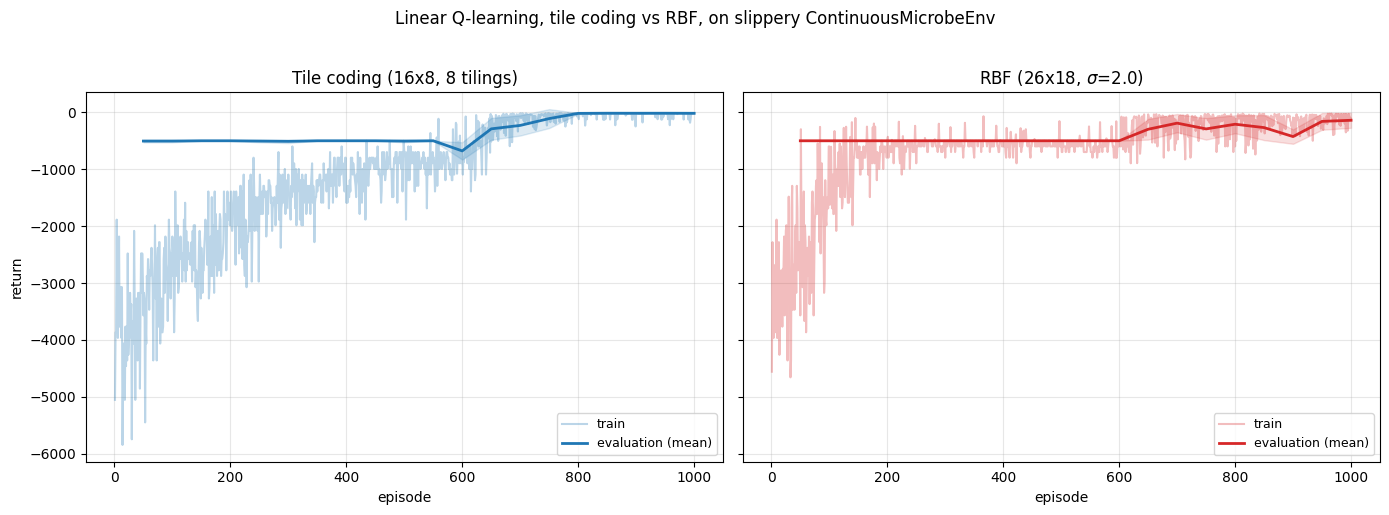

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax = axes[0]
train_eps_tc = np.arange(1, len(hist_tc.episode_returns) + 1)
ax.plot(train_eps_tc, hist_tc.episode_returns, alpha=0.3,
        color="#1f77b4", label="train")
ax.plot(hist_tc.eval_episodes, hist_tc.eval_mean_returns, color="#1f77b4",
        linewidth=2, label="evaluation (mean)")
ax.fill_between(
    hist_tc.eval_episodes,
    np.array(hist_tc.eval_mean_returns) - np.array(hist_tc.eval_std_returns),
    np.array(hist_tc.eval_mean_returns) + np.array(hist_tc.eval_std_returns),
    color="#1f77b4", alpha=0.15,
)
ax.set_title(f"Tile coding ({TC_N_TILES_X}x{TC_N_TILES_Y}, {TC_N_TILINGS} tilings)")
ax.set_xlabel("episode"); ax.set_ylabel("return")
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=9)

ax = axes[1]
train_eps_rbf = np.arange(1, len(hist_rbf.episode_returns) + 1)
ax.plot(train_eps_rbf, hist_rbf.episode_returns, alpha=0.3,
        color="#d62728", label="train")
ax.plot(hist_rbf.eval_episodes, hist_rbf.eval_mean_returns, color="#d62728",
        linewidth=2, label="evaluation (mean)")
ax.fill_between(
    hist_rbf.eval_episodes,
    np.array(hist_rbf.eval_mean_returns) - np.array(hist_rbf.eval_std_returns),
    np.array(hist_rbf.eval_mean_returns) + np.array(hist_rbf.eval_std_returns),
    color="#d62728", alpha=0.15,
)
ax.set_title(f"RBF ({RBF_N_CENTERS_X}x{RBF_N_CENTERS_Y}, $\\sigma$={RBF_SIGMA})")
ax.set_xlabel("episode")
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=9)

fig.suptitle("Linear Q-learning, tile coding vs RBF, on slippery ContinuousMicrobeEnv",
             y=1.02)
fig.tight_layout()
plt.show()

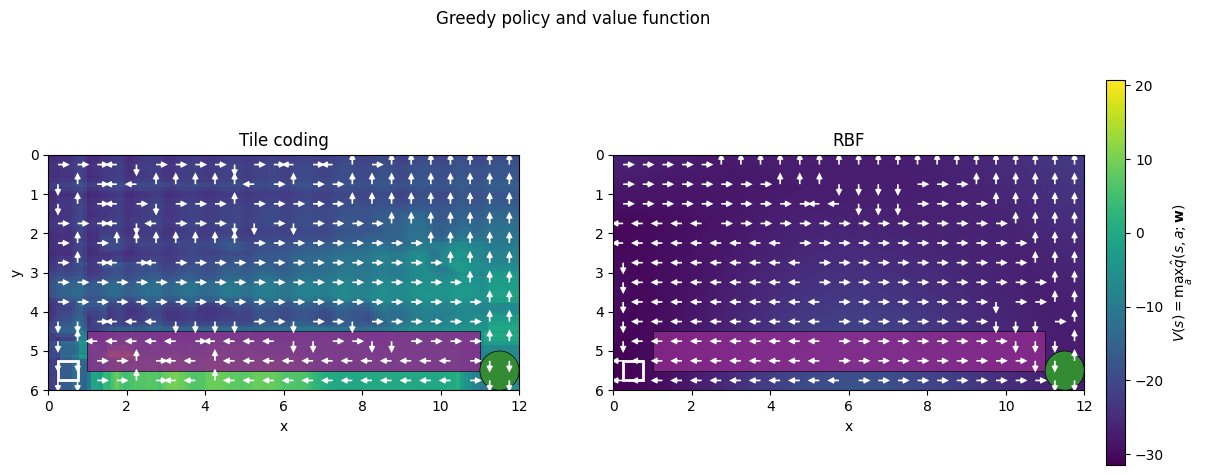

In [37]:
# Evaluate V on a fine grid for the heatmap.
def evaluate_v_on_grid(agent, n_eval=120):
    xs = np.linspace(LOW[0], HIGH[0], n_eval)
    ys = np.linspace(LOW[1], HIGH[1], n_eval)
    XX, YY = np.meshgrid(xs, ys)
    V = np.zeros((n_eval, n_eval), dtype=np.float64)
    for i in range(n_eval):
        for j in range(n_eval):
            V[i, j] = agent.state_value(np.array([XX[i, j], YY[i, j]]))
    return V

V_tc = evaluate_v_on_grid(tc_agent)
V_rbf = evaluate_v_on_grid(rbf_agent)
vmin = min(V_tc.min(), V_rbf.min())
vmax = max(V_tc.max(), V_rbf.max())

# Sample greedy actions on a coarser grid for the arrows.
def sample_greedy_arrows(agent, n_x=24, n_y=12):
    xs = np.linspace(LOW[0] + 0.25, HIGH[0] - 0.25, n_x)
    ys = np.linspace(LOW[1] + 0.25, HIGH[1] - 0.25, n_y)
    arrow_dx_dy = {
        0: (0.0, -1.0),  # up: y decreases
        1: (+1.0, 0.0),  # right
        2: (0.0, +1.0),  # down: y increases
        3: (-1.0, 0.0),  # left
    }
    XX, YY, DX, DY = [], [], [], []
    for x in xs:
        for y in ys:
            s = np.array([x, y])
            a = agent.greedy_action(s)
            dx, dy = arrow_dx_dy[a]
            XX.append(x); YY.append(y); DX.append(dx); DY.append(dy)
    return np.array(XX), np.array(YY), np.array(DX), np.array(DY)

XX_tc, YY_tc, DX_tc, DY_tc = sample_greedy_arrows(tc_agent)
XX_rbf, YY_rbf, DX_rbf, DY_rbf = sample_greedy_arrows(rbf_agent)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, V, XX, YY, DX, DY, title in [
    (axes[0], V_tc, XX_tc, YY_tc, DX_tc, DY_tc, "Tile coding"),
    (axes[1], V_rbf, XX_rbf, YY_rbf, DX_rbf, DY_rbf, "RBF"),
]:
    im = ax.imshow(V, origin="upper",
                   extent=(LOW[0], HIGH[0], HIGH[1], LOW[1]),
                   cmap="viridis", vmin=vmin, vmax=vmax,
                   interpolation="nearest", aspect="equal")
    ax.add_patch(plt.Rectangle((1.0, 4.5), 10.0, 1.0,
                               facecolor="#8c2a8c", edgecolor="black",
                               linewidth=0.5, alpha=0.85))
    ax.add_patch(plt.Circle((11.5, 5.5), 0.5,
                            facecolor="#338c33", edgecolor="black",
                            linewidth=0.5))
    ax.add_patch(plt.Rectangle((0.25, 5.25), 0.5, 0.5,
                               fill=False, edgecolor="white", linewidth=2.0))
    ax.quiver(XX, YY, DX, DY,
              color="white", scale=40, width=0.0035,
              headwidth=4, headlength=4)
    ax.set_xlim(0.0, HIGH[0]); ax.set_ylim(HIGH[1], 0.0)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_title(title)

axes[0].set_ylabel("y")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02,
             label=r"$V(s) = \max_a \hat{q}(s, a; \mathbf{w})$")
fig.suptitle("Greedy policy and value function", y=1.02)
plt.show()

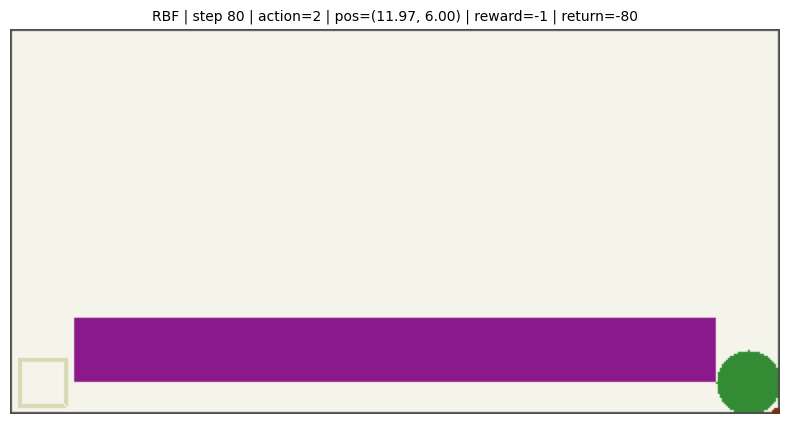

RBF ended after 80 steps with return -80.


In [38]:
def show_frame(frame, title):
    plt.figure(figsize=(10, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

FRAME_DELAY = 0.25
ROLLOUT_MAX_STEPS = 80
ROLLOUT_SEED = MASTER_SEED + 100

def run_greedy_rollout(agent, label):
    env = ContinuousMicrobeEnv(noise=NOISE, render_mode="rgb_array")
    obs, _ = env.reset(seed=ROLLOUT_SEED)
    ep_step, ep_return = 0, 0.0
    show_frame(env.render(),
               title=f"{label} | step 0 | pos=({obs[0]:.2f}, {obs[1]:.2f})")
    time.sleep(FRAME_DELAY)
    for _ in range(ROLLOUT_MAX_STEPS):
        action = agent.select_action(obs, greedy=True)
        obs, reward, terminated, truncated, info = env.step(action)
        ep_step += 1
        ep_return += reward
        clear_output(wait=True)
        show_frame(
            env.render(),
            title=(f"{label} | step {ep_step} | action={action} | "
                   f"pos=({obs[0]:.2f}, {obs[1]:.2f}) | reward={reward:.0f} | "
                   f"return={ep_return:.0f}")
        )
        time.sleep(FRAME_DELAY)
        if terminated or truncated:
            break
    env.close()
    print(f"{label} ended after {ep_step} steps with return {ep_return:.0f}.")

run_greedy_rollout(tc_agent, "Tile coding")
run_greedy_rollout(rbf_agent, "RBF")